# COMP20008 Assignment 2 — Squirrel Behaviour Analysis

**Research Question:** Which behavioural and environmental factors are most strongly associated with squirrel approaches toward humans in Central Park, and can we reliably predict this behaviour?

**Pipeline:** EDA → Preprocessing → Correlation Analysis → Supervised Learning → Clustering

## 0. Imports

In [177]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, KBinsDiscretizer
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    normalized_mutual_info_score, adjusted_rand_score, silhouette_score
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline


from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

print('Libraries loaded successfully')

Libraries loaded successfully


## 1. Load Data

In [178]:
DATA_DIR = '.'  # change this if needed
squirrel = pd.read_csv(os.path.join(DATA_DIR, 'squirrel.csv'))
hectare  = pd.read_csv(os.path.join(DATA_DIR, 'hectare.csv'))
stories  = pd.read_csv(os.path.join(DATA_DIR, 'stories.csv'))

print('squirrel shape:', squirrel.shape)
print('hectare shape: ', hectare.shape)
print('stories shape: ', stories.shape)

squirrel shape: (3023, 31)
hectare shape:  (700, 13)
stories shape:  (809, 12)


## 2. Exploratory Data Analysis (EDA)

In [179]:
squirrel.info()

<class 'pandas.DataFrame'>
RangeIndex: 3023 entries, 0 to 3022
Data columns (total 31 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   X                                           3023 non-null   float64
 1   Y                                           3023 non-null   float64
 2   Unique Squirrel ID                          3023 non-null   str    
 3   Hectare                                     3023 non-null   str    
 4   Shift                                       3023 non-null   str    
 5   Date                                        3023 non-null   int64  
 6   Hectare Squirrel Number                     3023 non-null   int64  
 7   Age                                         2902 non-null   str    
 8   Primary Fur Color                           2968 non-null   str    
 9   Highlight Fur Color                         1937 non-null   str    
 10  Combination of Primary 

In [180]:
squirrel.head()

,X,Y,Unique Squirrel ID,Hectare,Shift,Date,Hectare Squirrel Number,Age,Primary Fur Color,Highlight Fur Color,Combination of Primary and Highlight Color,Color notes,Location,Above Ground Sighter Measurement,Specific Location,Running,Chasing,Climbing,Eating,Foraging,Other Activities,Kuks,Quaas,Moans,Tail flags,Tail twitches,Approaches,Indifferent,Runs from,Other Interactions,Lat/Long
0,-73.956134,40.794082,37F-PM-1014-03,37F,PM,10142018,3,NaN,NaN,NaN,+,NaN,NaN,NaN,NaN,False,False,False,False,False,NaN,False,False,False,False,False,False,False,False,NaN,POINT (-73.9561344937861 40.7940823884086)
1,-73.968857,40.783783,21B-AM-1019-04,21B,AM,10192018,4,NaN,NaN,NaN,+,NaN,NaN,NaN,NaN,False,False,False,False,False,NaN,False,False,False,False,False,False,False,False,NaN,POINT (-73.9688574691102 40.7837825208444)
2,-73.974281,40.775534,11B-PM-1014-08,11B,PM,10142018,8,NaN,Gray,NaN,Gray+,NaN,Above Ground,10,NaN,False,True,False,False,False,NaN,False,False,False,False,False,False,False,False,NaN,POINT (-73.97428114848522 40.775533619083)
3,-73.959641,40.790313,32E-PM-1017-14,32E,PM,10172018,14,Adult,Gray,NaN,Gray+,Nothing selected as Primary. Gray selected as ...,NaN,NaN,NaN,False,False,False,True,True,NaN,False,False,False,False,False,False,False,True,NaN,POINT (-73.9596413903948 40.7903128889029)
4,-73.970268,40.776213,13E-AM-1017-05,13E,AM,10172018,5,Adult,Gray,Cinnamon,Gray+Cinnamon,NaN,Above Ground,NaN,on tree stump,False,False,False,False,True,NaN,False,False,False,False,False,False,False,False,NaN,POINT (-73.9702676472613 40.7762126854894)


In [181]:
# Missing values summary
missing = squirrel.isnull().sum()
missing_pct = (missing / len(squirrel) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

,Missing Count,Missing %
Color notes,2841,93.98
Other Interactions,2783,92.06
Other Activities,2586,85.54
Specific Location,2547,84.25
Highlight Fur Color,1086,35.92
Age,121,4.00
Above Ground Sighter Measurement,114,3.77
Location,64,2.12
Primary Fur Color,55,1.82


In [182]:
# Target variable distribution — note class imbalance
print('Approaches distribution:')
print(squirrel['Approaches'].value_counts())
print(f'\nClass balance: {squirrel["Approaches"].value_counts(normalize=True).round(3).to_dict()}')
# ~94% false, ~6% true — significant imbalance, must be addressed in modelling

Approaches distribution:
Approaches
False    2845
True      178
Name: count, dtype: int64

Class balance: {False: 0.941, True: 0.059}


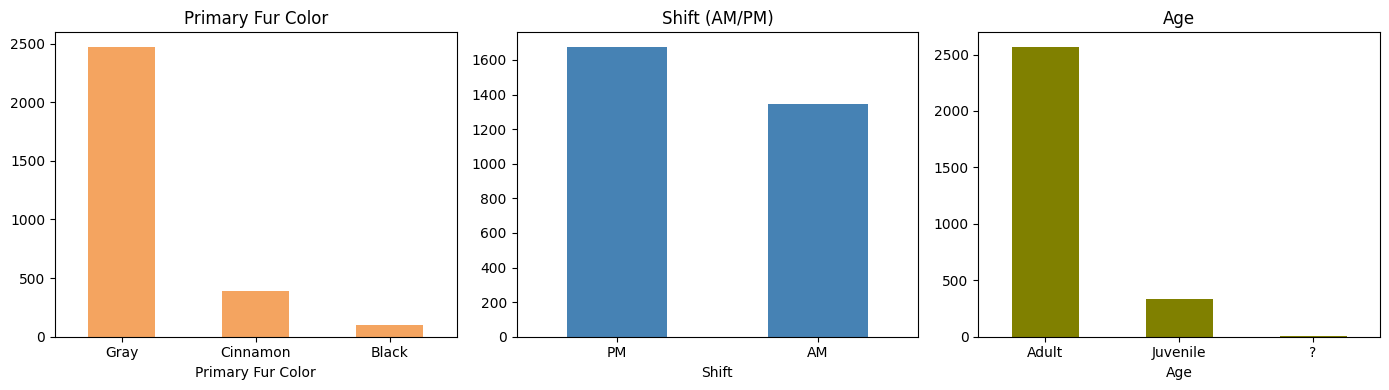

Primary Fur Color
Gray        83.3
Cinnamon    13.2
Black        3.5
Name: proportion, dtype: float64
Shift
PM    55.4
AM    44.6
Name: proportion, dtype: float64
Age
Adult       88.5
Juvenile    11.4
?            0.1
Name: proportion, dtype: float64


In [183]:
# Distribution of categorical features
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

squirrel['Primary Fur Color'].value_counts().plot(kind='bar', ax=axes[0], color='sandybrown')
axes[0].set_title('Primary Fur Color')
axes[0].tick_params(axis='x', rotation=0)

squirrel['Shift'].value_counts().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Shift (AM/PM)')
axes[1].tick_params(axis='x', rotation=0)

squirrel['Age'].value_counts().plot(kind='bar', ax=axes[2], color='olive')
axes[2].set_title('Age')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

print(squirrel['Primary Fur Color'].value_counts(normalize=True).mul(100).round(1))
print(squirrel['Shift'].value_counts(normalize=True).mul(100).round(1))
print(squirrel['Age'].value_counts(normalize=True).mul(100).round(1))

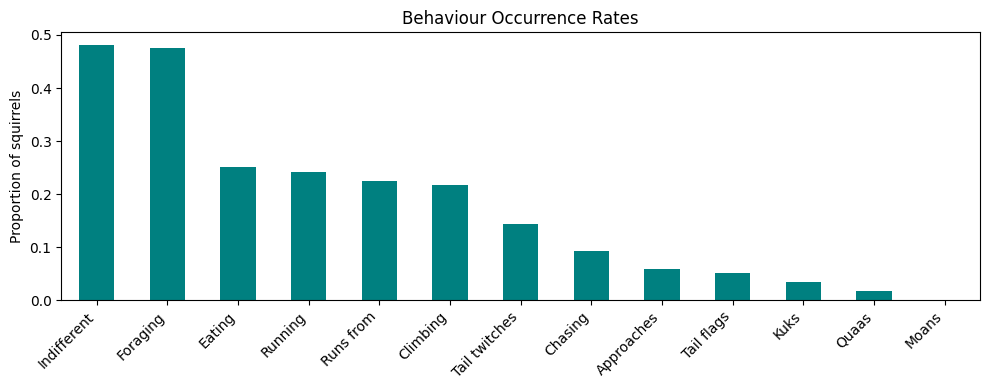

Indifferent      48.1
Foraging         47.5
Eating           25.1
Running          24.1
Runs from        22.4
Climbing         21.8
Tail twitches    14.4
Chasing           9.2
Approaches        5.9
Tail flags        5.1
Kuks              3.4
Quaas             1.7
Moans             0.1
dtype: float64


In [184]:
# Convert boolean columns from string/bool to int
behaviour_cols = ['Running','Chasing','Climbing','Eating','Foraging',
                  'Kuks','Quaas','Moans','Tail flags','Tail twitches',
                  'Approaches','Indifferent','Runs from']

for col in behaviour_cols:
    squirrel[col] = squirrel[col].map(
        {'true': 1, 'false': 0, True: 1, False: 0}
    ).fillna(0).astype(int)

# Behaviour occurrence rates
behaviour_rates = squirrel[behaviour_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
behaviour_rates.plot(kind='bar', color='teal')
plt.title('Behaviour Occurrence Rates')
plt.ylabel('Proportion of squirrels')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('eda_behaviour_rates.png', dpi=150, bbox_inches='tight')
plt.show()

print((behaviour_rates * 100).round(1))

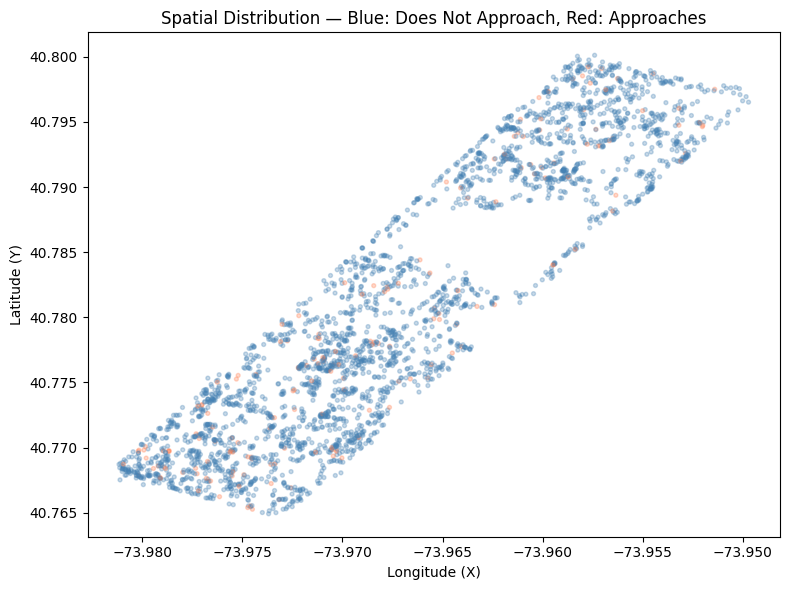

In [185]:
# Spatial distribution of squirrels coloured by Approaches
fig, ax = plt.subplots(figsize=(8, 6))
colors = squirrel['Approaches'].map({0: 'steelblue', 1: 'coral'})
ax.scatter(squirrel['X'], squirrel['Y'], c=colors, alpha=0.3, s=8)
ax.set_xlabel('Longitude (X)')
ax.set_ylabel('Latitude (Y)')
ax.set_title('Spatial Distribution — Blue: Does Not Approach, Red: Approaches')
plt.tight_layout()
plt.savefig('eda_spatial.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Preprocessing

In [186]:
# 3.1 Drop high-missing and irrelevant columns
# Justification:
# - Color notes (94% missing): too sparse to be useful
# - Specific Location (84% missing): too sparse
# - Other Activities/Interactions (85-92% missing): too sparse
# - Combination of colors, Lat/Long: redundant with other features
# - Unique Squirrel ID, Date, Hectare Squirrel Number: identifiers, not predictive
# Alternative considered: imputation — rejected because >50% missing makes imputation unreliable

cols_to_drop = [
    'Color notes', 'Specific Location', 'Other Activities',
    'Other Interactions', 'Highlight Fur Color',
    'Combination of Primary and Highlight Color', 'Lat/Long',
    'Unique Squirrel ID', 'Date', 'Hectare Squirrel Number'
]
df = squirrel.drop(columns=cols_to_drop)
print('Shape after dropping columns:', df.shape)

Shape after dropping columns: (3023, 21)


In [187]:
# 3.2 Data Validation — check for range errors and format inconsistencies
# Above Ground Sighter Measurement has mixed 'FALSE' strings and numeric values
print('Above Ground Sighter Measurement unique values (sample):')
print(df['Above Ground Sighter Measurement'].value_counts().head(10))

# Convert 'FALSE' strings to 0 (ground level), then to numeric
df['Above Ground Sighter Measurement'] = df['Above Ground Sighter Measurement'].replace('FALSE', 0)
df['Above Ground Sighter Measurement'] = pd.to_numeric(
    df['Above Ground Sighter Measurement'], errors='coerce'
).fillna(0)

# Validate coordinate ranges (Central Park bounds approximately)
print('\nX range:', df['X'].min(), '-', df['X'].max())
print('Y range:', df['Y'].min(), '-', df['Y'].max())

# Flag any outlier coordinates outside expected Central Park bounds
coord_errors = df[(df['X'] < -73.99) | (df['X'] > -73.94) | 
                   (df['Y'] < 40.76) | (df['Y'] > 40.80)]
print(f'\nCoordinate outliers found: {len(coord_errors)}')

Above Ground Sighter Measurement unique values (sample):
Above Ground Sighter Measurement
FALSE    2116
10        116
20         84
15         71
2          55
3          52
5          51
30         44
4          42
25         33
Name: count, dtype: int64

X range: -73.98115858076 - -73.94972176746
Y range: 40.76491066771 - 40.80011851849

Coordinate outliers found: 2


In [188]:
# 3.3 Handle missing values
# Justification for each choice:
# - Primary Fur Color (1.8%): mode imputation — categorical, majority is Gray
# - Age (4%): mode imputation — categorical, mostly Adult
# - Location (2.1%): mode imputation — categorical
# Alternative considered: dropping rows — rejected because 4% is small but non-trivial loss

df['Primary Fur Color'] = df['Primary Fur Color'].fillna(df['Primary Fur Color'].mode()[0])
df['Age'] = df['Age'].fillna(df['Age'].mode()[0])
df['Location'] = df['Location'].fillna(df['Location'].mode()[0])

print('Missing values after handling:')
remaining = df.isnull().sum()
print(remaining[remaining > 0] if remaining[remaining > 0].any() else 'None remaining')

Missing values after handling:
None remaining


In [189]:
# 3.4 Feature Engineering
# Justification: combining related binary indicators into composite scores
# reduces dimensionality and creates more interpretable features

# Activity score: how physically active is the squirrel?
active_behaviours = ['Running', 'Chasing', 'Climbing', 'Eating', 'Foraging']
df['Activity Score'] = df[active_behaviours].sum(axis=1)

# Vocal/alarm score: how much distress signalling?
vocal_behaviours = ['Kuks', 'Quaas', 'Moans', 'Tail flags', 'Tail twitches']
df['Vocal Score'] = df[vocal_behaviours].sum(axis=1)

# Human interaction score (excluding target): does it avoid or ignore humans?
df['Human Interaction Score'] = df['Indifferent'] + df['Runs from']

print('New engineered features:')
df[['Activity Score', 'Vocal Score', 'Human Interaction Score']].describe()

New engineered features:


,Activity Score,Vocal Score,Human Interaction Score
count,3023.000000,3023.000000,3023.00000
mean,1.277539,0.246113,0.70526
std,0.683585,0.487057,0.47866
min,0.000000,0.000000,0.00000
25%,1.000000,0.000000,0.00000
50%,1.000000,0.000000,1.00000
75%,2.000000,0.000000,1.00000
max,5.000000,4.000000,2.00000


In [190]:
# 3.5 Data Integration — merge with hectare data
# Justification: hectare data provides environmental context (weather, observer count)
# that may influence squirrel behaviour
hectare_useful = hectare[['Hectare', 'Shift', 'Sighter Observed Weather Data',
                           'Litter', 'Number of sighters', 'Number of Squirrels']].copy()

df = df.merge(hectare_useful, on=['Hectare', 'Shift'], how='left')

# Fill missing values introduced by merge
df['Sighter Observed Weather Data'].fillna('Unknown', inplace=True)
df['Litter'].fillna('None', inplace=True)
df['Number of sighters'].fillna(df['Number of sighters'].median(), inplace=True)
df['Number of Squirrels'].fillna(df['Number of Squirrels'].median(), inplace=True)

print('Shape after merge with hectare:', df.shape)

Shape after merge with hectare: (3023, 28)


In [191]:
# 3.6 Encode categorical variables using LabelEncoder
le = LabelEncoder()
cat_cols = ['Shift', 'Age', 'Primary Fur Color', 'Location',
            'Sighter Observed Weather Data', 'Litter', 'Hectare']

for col in cat_cols:
    if col in df.columns:
        df[col + '_enc'] = le.fit_transform(df[col].astype(str))

print('Encoded columns created')

Encoded columns created


In [192]:
# 3.7 Handle class imbalance via stratified undersampling
# Justification: Approaches is 94% false vs 6% true — naive model would just predict false
# Stratified undersampling preserves distribution of other key features
# Alternative: SMOTE (oversampling) — considered but undersampling chosen to avoid
# introducing synthetic data that may not reflect real squirrel behaviour

df_majority = df[df['Approaches'] == 0]
df_minority = df[df['Approaches'] == 1]

n_minority = len(df_minority)  # 178

# Stratified undersample majority by Primary Fur Color
sampled_majority_groups = []
for fur_color, group in df_majority.groupby('Primary Fur Color'):
    proportion = len(group) / len(df_majority)
    n_sample = max(1, round(proportion * n_minority))
    sampled_majority_groups.append(group.sample(n=min(n_sample, len(group)), random_state=42))

df_majority_sampled = pd.concat(sampled_majority_groups)
df_balanced = pd.concat([df_majority_sampled, df_minority]).reset_index(drop=True)

print('Class distribution after stratified undersampling:')
print(df_balanced['Approaches'].value_counts())
print(f'\nOriginal size: {len(df)} → Balanced size: {len(df_balanced)}')

Class distribution after stratified undersampling:
Approaches
0    178
1    178
Name: count, dtype: int64

Original size: 3023 → Balanced size: 356


In [193]:
# 3.8 Prepare final feature set
feature_cols = [
    'X', 'Y',
    'Shift_enc', 'Age_enc', 'Primary Fur Color_enc', 'Location_enc',
    'Above Ground Sighter Measurement',
    'Running', 'Chasing', 'Climbing', 'Eating', 'Foraging',
    'Kuks', 'Quaas', 'Moans', 'Tail flags', 'Tail twitches',
    'Indifferent', 'Runs from',
    'Activity Score', 'Vocal Score', 'Human Interaction Score',
    'Number of sighters', 'Number of Squirrels',
    'Sighter Observed Weather Data_enc'
]
target_col = 'Approaches'

X = df_balanced[feature_cols]
y = df_balanced[target_col]

print('Feature matrix shape:', X.shape)
print('Target distribution:', y.value_counts().to_dict())

# Safety: fill any residual NaN
X = X.fillna(X.median())
y = y.fillna(0)

Feature matrix shape: (356, 25)
Target distribution: {0: 178, 1: 178}


## 3.9 Preprocessing Impact — Before vs After Comparison

In [194]:
# 3.9 Preprocessing Impact Analysis
# Compare model performance BEFORE undersampling vs AFTER
# Must run AFTER cell 20 (df_balanced defined) and cell 21 (X, y defined)

from sklearn.metrics import f1_score, precision_score, recall_score

# --- Config 1: NAIVE — no imbalance handling, full dataset ---
X_full = df[feature_cols]
y_full = df[target_col]
X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)
dt_naive = DecisionTreeClassifier(criterion="entropy", max_depth=5, random_state=42)
dt_naive.fit(X_tr_f, y_tr_f)
y_pred_naive = dt_naive.predict(X_te_f)

# --- Config 2: class_weight balanced — full dataset ---
dt_weighted = DecisionTreeClassifier(
    criterion="entropy", max_depth=5, class_weight="balanced", random_state=42
)
dt_weighted.fit(X_tr_f, y_tr_f)
y_pred_weighted = dt_weighted.predict(X_te_f)

# --- Config 3: stratified undersampling (already done in cell 20/21) ---
# X_train / X_test / y_train / y_test are from df_balanced (defined in cell 34)
# Note: we re-use the DT trained in cell 35 (dt)
# But cell 35 runs later, so we retrain here for the comparison
# --- Config 3: stratified undersampling ---
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
dt_balanced_cmp = DecisionTreeClassifier(
    criterion="entropy", max_depth=5, class_weight="balanced", random_state=42
)
dt_balanced_cmp.fit(X_tr_b, y_tr_b)
y_pred_balanced_cmp = dt_balanced_cmp.predict(X_te_b)

def metrics_dict(y_true, y_pred):
    return {
        "Accuracy":           round((y_true == y_pred).mean(), 3),
        "F1 (Approaches)":    round(f1_score(y_true, y_pred, pos_label=1, zero_division=0), 3),
        "Recall (Approaches)": round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 3),
        "Precision (Approaches)": round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 3),
    }

impact_df = pd.DataFrame({
    "Naive (no balancing)":       metrics_dict(y_te_f, y_pred_naive),
    "class_weight=balanced":      metrics_dict(y_te_f, y_pred_weighted),
    "Stratified undersampling": metrics_dict(y_te_b, y_pred_balanced_cmp),
}).T

print("=== Impact of class imbalance handling on Decision Tree ===")
print(impact_df)
print("\nNote: Accuracy is misleading on imbalanced data.")
print("F1 and Recall for Approaches (minority class) are the key metrics.")


=== Impact of class imbalance handling on Decision Tree ===
                          Accuracy  F1 (Approaches)  Recall (Approaches)  \
Naive (no balancing)         0.936            0.000                0.000   
class_weight=balanced        0.795            0.326                0.833   
Stratified undersampling     0.694            0.694                0.694   

                          Precision (Approaches)  
Naive (no balancing)                       0.000  
class_weight=balanced                      0.203  
Stratified undersampling                   0.694  

Note: Accuracy is misleading on imbalanced data.
F1 and Recall for Approaches (minority class) are the key metrics.


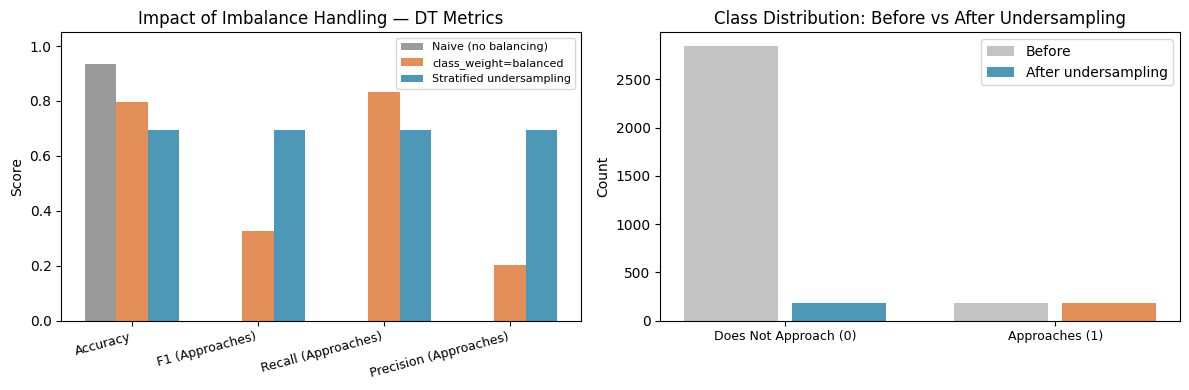

In [195]:
# Visualise the impact comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

metrics = ["Accuracy", "F1 (Approaches)", "Recall (Approaches)", "Precision (Approaches)"]
x = np.arange(len(metrics))
width = 0.25
colors = ["#888", "#e07b39", "#2e86ab"]

for i, (label, row) in enumerate(impact_df.iterrows()):
    axes[0].bar(x + i*width, row[metrics], width, label=label, color=colors[i], alpha=0.85)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics, rotation=15, ha="right", fontsize=9)
axes[0].set_title("Impact of Imbalance Handling — DT Metrics")
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=8)
axes[0].set_ylabel("Score")

# Class distribution before vs after
before = pd.Series({"Does Not Approach (0)": (y_full==0).sum(), "Approaches (1)": (y_full==1).sum()})
after  = pd.Series({"Does Not Approach (0)": (y==0).sum(), "Approaches (1)": (y==1).sum()})

axes[1].bar([0, 1], before.values, width=0.35, label="Before", color=["#aaa", "#aaa"], alpha=0.7)
axes[1].bar([0.4, 1.4], after.values, width=0.35, label="After undersampling", color=["#2e86ab", "#e07b39"], alpha=0.85)
axes[1].set_xticks([0.2, 1.2])
axes[1].set_xticklabels(["Does Not Approach (0)", "Approaches (1)"], fontsize=9)
axes[1].set_title("Class Distribution: Before vs After Undersampling")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig("preprocessing_impact.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Correlation Analysis

In [196]:
# Helper functions (from workshop)
def compute_probability(col):
    return col.value_counts() / col.shape[0]

def compute_entropy(col):
    probabilities = compute_probability(col)
    return -sum(probabilities * np.log2(probabilities + 1e-10))

def compute_conditional_entropy(x, y):
    probability_x = compute_probability(x)
    temp_df = pd.DataFrame({'X': x.values, 'Y': y.values})
    entropy_by_group = temp_df.groupby('X')['Y'].aggregate(compute_entropy)
    return sum(probability_x * entropy_by_group)

def compute_nmi(x, y):
    entropy_x = compute_entropy(x)
    entropy_y = compute_entropy(y)
    conditional = compute_conditional_entropy(x, y)
    mi = entropy_y - conditional
    return mi / min(entropy_x, entropy_y) if min(entropy_x, entropy_y) > 0 else 0

print('Helper functions defined')

Helper functions defined


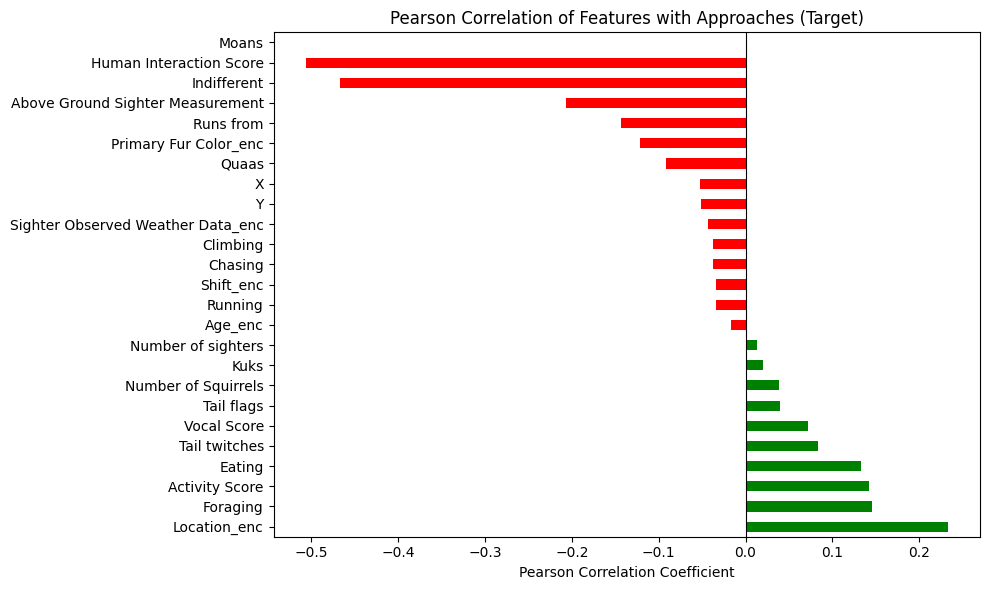

Top positive correlations:
Location_enc      0.233074
Foraging          0.146104
Activity Score    0.142034
Eating            0.133082
Tail twitches     0.083098
dtype: float64

Top negative correlations:
Runs from                          -0.143532
Above Ground Sighter Measurement   -0.206739
Indifferent                        -0.467477
Human Interaction Score            -0.506619
Moans                                    NaN
dtype: float64
Top 10 correlations with Approaches:
Location_enc           0.2331
Foraging               0.1461
Activity Score         0.1420
Eating                 0.1331
Tail twitches          0.0831
Vocal Score            0.0724
Tail flags             0.0395
Number of Squirrels    0.0380
Kuks                   0.0202
Number of sighters     0.0129
dtype: float64
Bottom 5 correlations:
Runs from                          -0.1435
Above Ground Sighter Measurement   -0.2067
Indifferent                        -0.4675
Human Interaction Score            -0.5066
Moans   

In [197]:
# 4.1 Pearson Correlation with target
# Justification: appropriate for continuous/binary features vs binary target
# Limitation: only captures linear relationships
corr_with_target = X.corrwith(y).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
corr_with_target.plot(
    kind='barh',
    color=['green' if v > 0 else 'red' for v in corr_with_target]
)
plt.title('Pearson Correlation of Features with Approaches (Target)')
plt.xlabel('Pearson Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('correlation_with_target.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top positive correlations:')
print(corr_with_target.head(5))
print('\nTop negative correlations:')
print(corr_with_target.tail(5))

# Print exact values for report
print("Top 10 correlations with Approaches:")
print(corr_with_target.head(10).round(4))
print("Bottom 5 correlations:")
print(corr_with_target.tail(5).round(4))

print("\nX and Y correlations:")
print(corr_with_target[['X', 'Y']].round(4))

In [198]:
# 4.2 Discretization for Mutual Information
# Justification: MI requires discrete variables; continuous features must be binned first
# Using equal-width binning (KBinsDiscretizer) with 3 bins as taught in workshop
# Alternative: equal-frequency — considered but equal-width more interpretable here

continuous_cols = ['X', 'Y', 'Above Ground Sighter Measurement',
                   'Activity Score', 'Vocal Score', 'Human Interaction Score',
                   'Number of sighters', 'Number of Squirrels']

# Fill any remaining NaN before discretizing
X_disc = X.copy()
X_disc = X_disc.fillna(X_disc.median())

discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='uniform')
X_disc[continuous_cols] = discretizer.fit_transform(X_disc[continuous_cols]).astype(int)

print('Continuous features discretized into 3 bins')
X_disc[continuous_cols].head(3)

Continuous features discretized into 3 bins


,X,Y,Above Ground Sighter Measurement,Activity Score,Vocal Score,Human Interaction Score,Number of sighters,Number of Squirrels
0,0,0,0,1,0,1,0,0
1,2,2,0,1,0,1,0,1
2,2,2,0,0,0,1,0,0


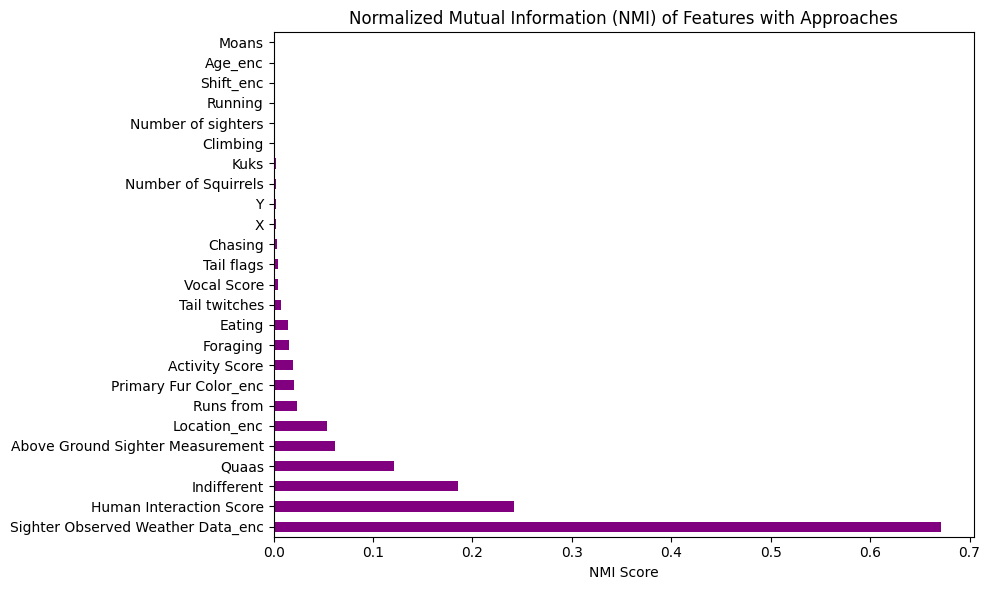

Top 5 features by NMI:
Sighter Observed Weather Data_enc    0.670858
Human Interaction Score              0.241702
Indifferent                          0.185078
Quaas                                0.120822
Above Ground Sighter Measurement     0.062204
dtype: float64


In [199]:
# 4.3 Normalized Mutual Information (NMI) with target
# Justification: captures non-linear relationships that Pearson misses
# NMI normalises MI to [0,1] for fair comparison across features

nmi_scores = {}
for col in feature_cols:
    nmi_scores[col] = normalized_mutual_info_score(
        X_disc[col].astype(int), y.astype(int), average_method='min'
    )

nmi_series = pd.Series(nmi_scores).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
nmi_series.plot(kind='barh', color='purple')
plt.title('Normalized Mutual Information (NMI) of Features with Approaches')
plt.xlabel('NMI Score')
plt.tight_layout()
plt.savefig('nmi_with_target.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features by NMI:')
print(nmi_series.head(5))

In [200]:
# 4.4 Compare Pearson vs NMI rankings
# This reveals which features have non-linear relationships with the target
comparison = pd.DataFrame({
    'Pearson (abs)': corr_with_target.abs(),
    'NMI': nmi_series
}).sort_values('NMI', ascending=False)

print('Pearson vs NMI comparison (top 10):')
comparison.head(10)

Pearson vs NMI comparison (top 10):


,Pearson (abs),NMI
Sighter Observed Weather Data_enc,0.043332,0.670858
Human Interaction Score,0.506619,0.241702
Indifferent,0.467477,0.185078
Quaas,0.092188,0.120822
Above Ground Sighter Measurement,0.206739,0.062204
Location_enc,0.233074,0.053907
Runs from,0.143532,0.023287
Primary Fur Color_enc,0.122064,0.020888
Activity Score,0.142034,0.019976
Foraging,0.146104,0.015459


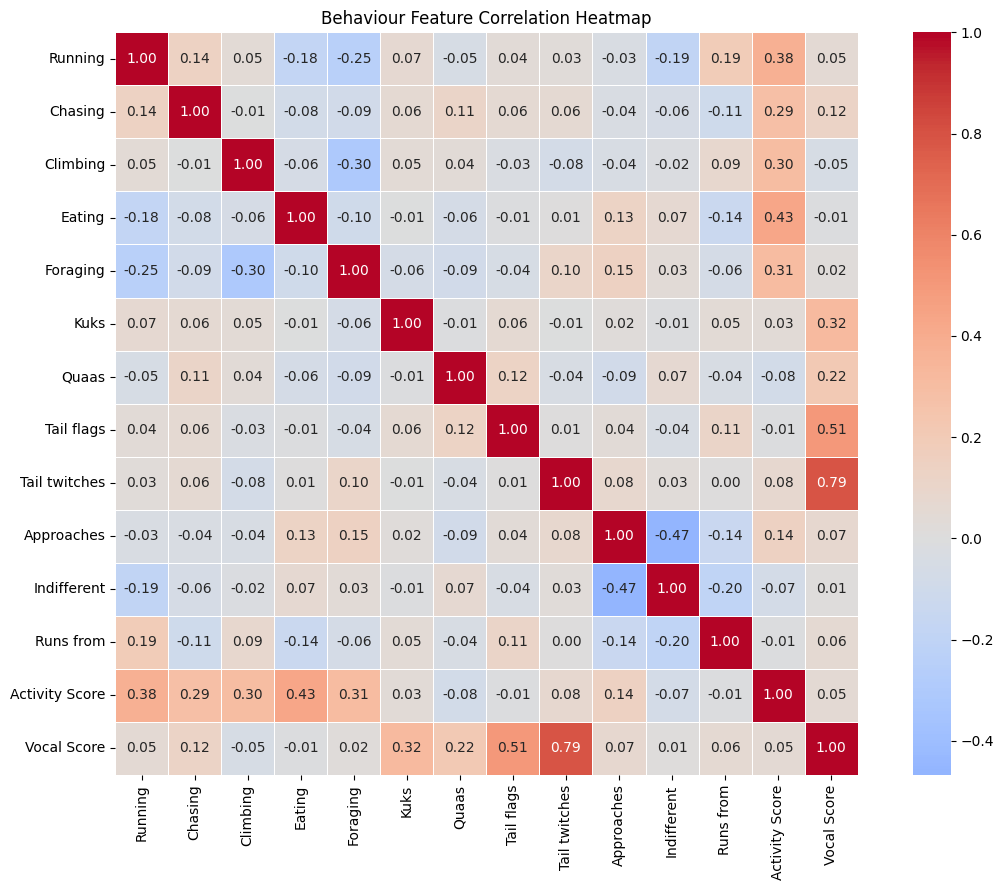

In [201]:
# 4.5 Correlation heatmap among behaviour features
behaviour_features = ['Running','Chasing','Climbing','Eating','Foraging',
                      'Kuks','Quaas','Tail flags','Tail twitches',
                      'Approaches','Indifferent','Runs from',
                      'Activity Score','Vocal Score']

corr_matrix = df_balanced[behaviour_features].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Behaviour Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

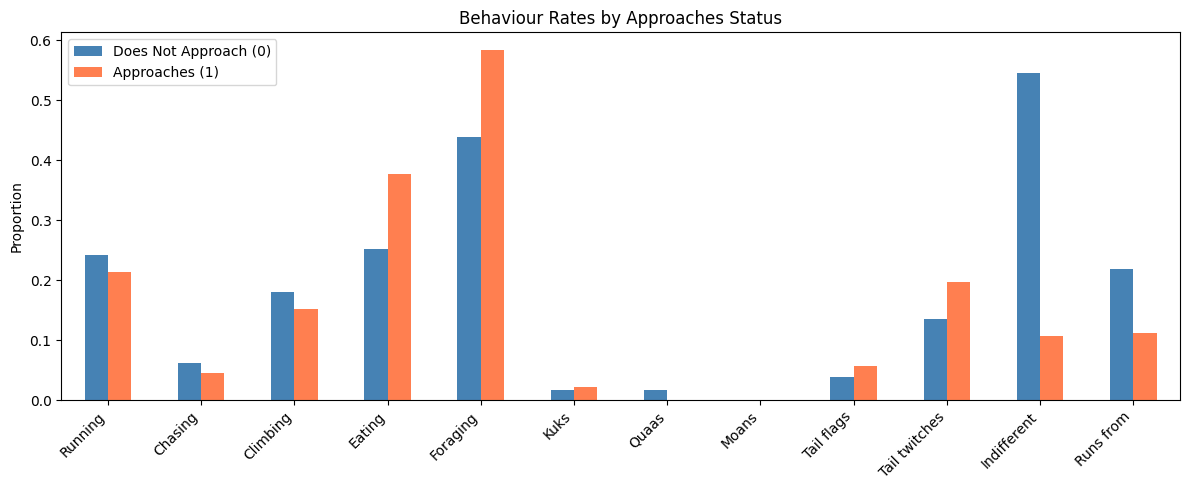

In [202]:
# 4.6 Behaviour rates: Approaches=1 vs Approaches=0
# Note phrasing: 'is associated with', not 'causes'
non_target_behaviours = [c for c in behaviour_cols if c != 'Approaches']
behaviour_by_approach = df_balanced.groupby('Approaches')[non_target_behaviours].mean()

behaviour_by_approach.T.plot(kind='bar', figsize=(12, 5),
                              color=['steelblue', 'coral'])
plt.title('Behaviour Rates by Approaches Status')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(['Does Not Approach (0)', 'Approaches (1)'])
plt.tight_layout()
plt.savefig('behaviour_by_approach.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Supervised Learning

In [203]:
# 5.1 Train/Test Split — stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', X_train.shape)
print('Test size: ', X_test.shape)
print('Train target distribution:', y_train.value_counts().to_dict())

Train size: (284, 25)
Test size:  (72, 25)
Train target distribution: {0: 142, 1: 142}


In [204]:
# 5.2 Model 1: Decision Tree
# Justification: interpretable, handles mixed feature types, can visualise decision rules
# criterion='entropy' uses Information Gain (as taught in workshop)
# class_weight='balanced' compensates for any remaining imbalance after undersampling
# max_depth=5 prevents overfitting
# Alternative: deeper tree — overfits; shallower tree — underfits

dt = DecisionTreeClassifier(
    criterion='entropy',       # Information Gain (from workshop)
    max_depth=5,
    class_weight='balanced',
    random_state=42
)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print('=== Decision Tree ===')
print(classification_report(y_test, y_pred_dt,
      target_names=['Does Not Approach', 'Approaches']))

=== Decision Tree ===
                   precision    recall  f1-score   support

Does Not Approach       0.69      0.69      0.69        36
       Approaches       0.69      0.69      0.69        36

         accuracy                           0.69        72
        macro avg       0.69      0.69      0.69        72
     weighted avg       0.69      0.69      0.69        72



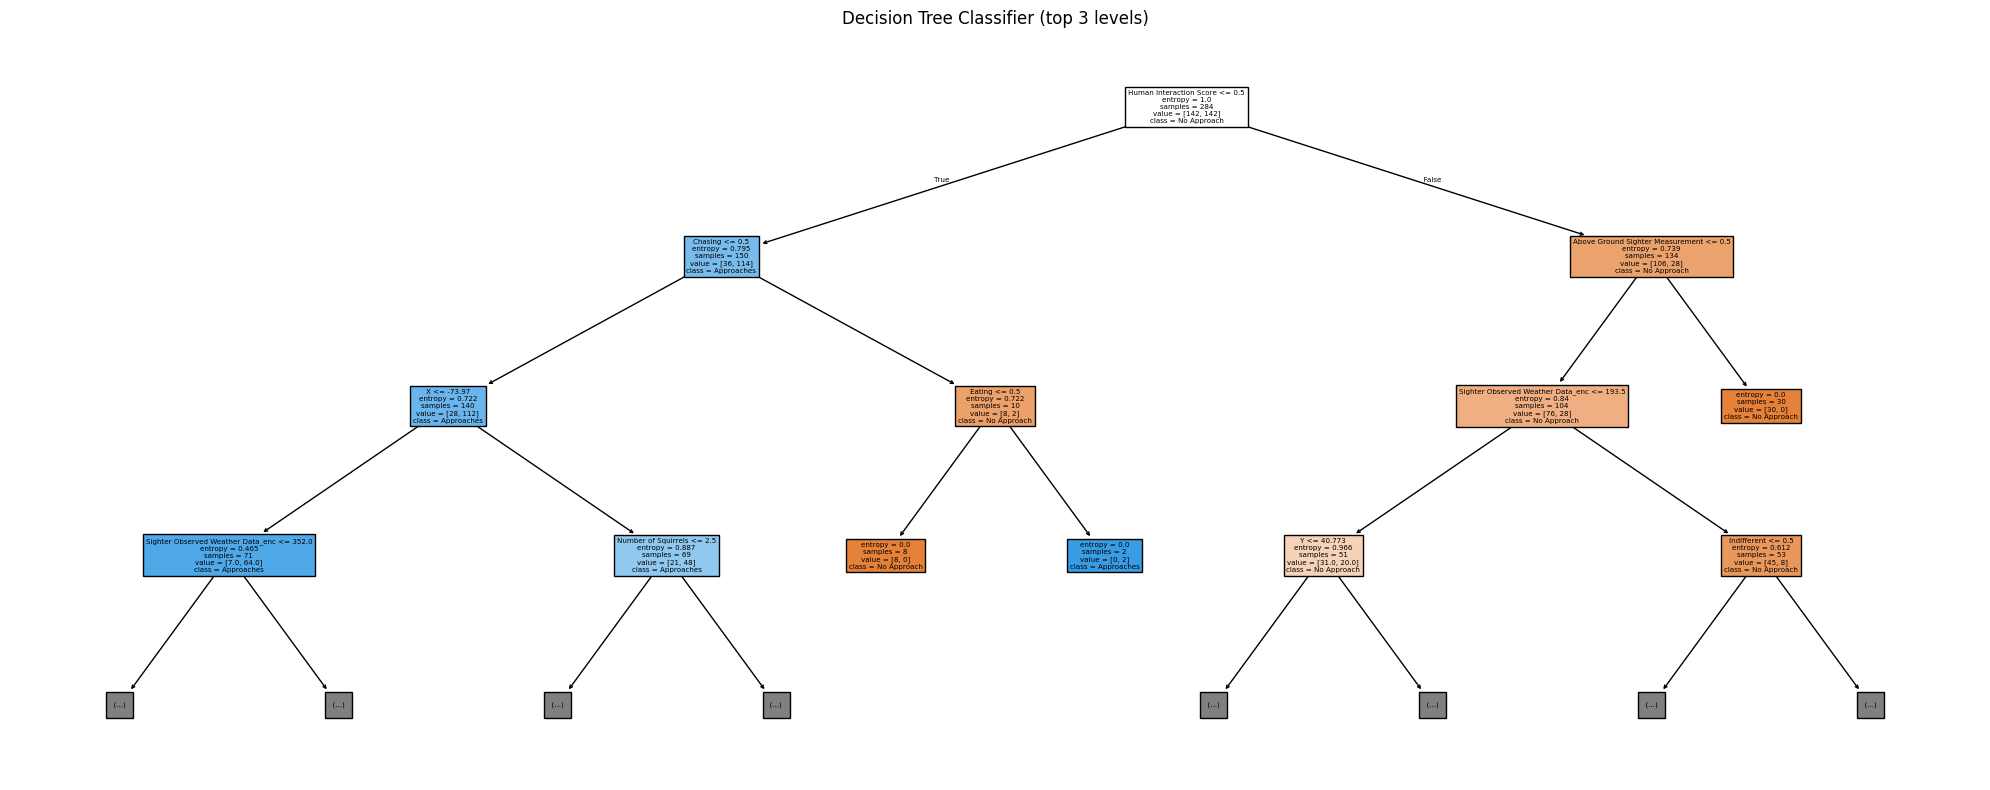

In [205]:
# Visualise the Decision Tree (as taught in workshop)
plt.figure(figsize=(20, 8))
plot_tree(
    dt,
    feature_names=feature_cols,
    class_names=['No Approach', 'Approaches'],
    filled=True,
    max_depth=3   # show top 3 levels for readability
)
plt.title('Decision Tree Classifier (top 3 levels)')
plt.tight_layout()
plt.savefig('decision_tree_viz.png', dpi=100, bbox_inches='tight')
plt.show()

Best k by CV F1: 20


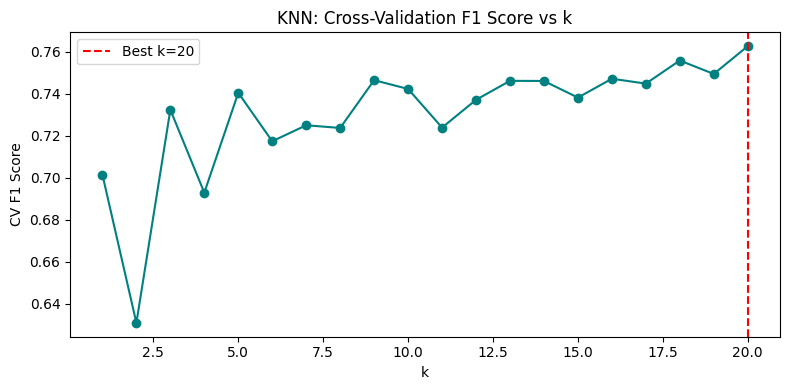

In [206]:
# 5.3 Model 2: K-Nearest Neighbours (KNN)
# Justification: non-parametric, no assumptions about data distribution,
# complements DT by using distance-based rather than rule-based classification
# Features must be scaled for KNN (distance-sensitive)
# Alternative k values explored via cross-validation below

# Find best k using cross-validation
# Pipeline wraps scaler + KNN together to prevent data leakage:
# each CV fold fits the scaler only on its own training split,
# not on the full X_train — this is the correct approach
from sklearn.pipeline import Pipeline

k_values = range(1, 21)
cv_scores = []
for k in k_values:
    pipe = Pipeline([
        ('scaler', MinMaxScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1')
    cv_scores.append(scores.mean())

best_k = k_values[np.argmax(cv_scores)]
print(f'Best k by CV F1: {best_k}')

# Plot k selection curve
plt.figure(figsize=(8, 4))
plt.plot(k_values, cv_scores, 'o-', color='teal')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('k')
plt.ylabel('CV F1 Score')
plt.title('KNN: Cross-Validation F1 Score vs k')
plt.legend()
plt.tight_layout()
plt.savefig('knn_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

# Train final KNN model using best k
# Scale manually here (outside Pipeline) so X_test_scaled is available
# for the confusion matrix and classification report below
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train.fillna(X_train.median()))
X_test_scaled  = scaler.transform(X_test.fillna(X_train.median()))

In [207]:
# Train final KNN with best k
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print(f'=== KNN (k={best_k}) ===')
print(classification_report(y_test, y_pred_knn,
      target_names=['Does Not Approach', 'Approaches']))

=== KNN (k=20) ===
                   precision    recall  f1-score   support

Does Not Approach       0.76      0.78      0.77        36
       Approaches       0.77      0.75      0.76        36

         accuracy                           0.76        72
        macro avg       0.76      0.76      0.76        72
     weighted avg       0.76      0.76      0.76        72



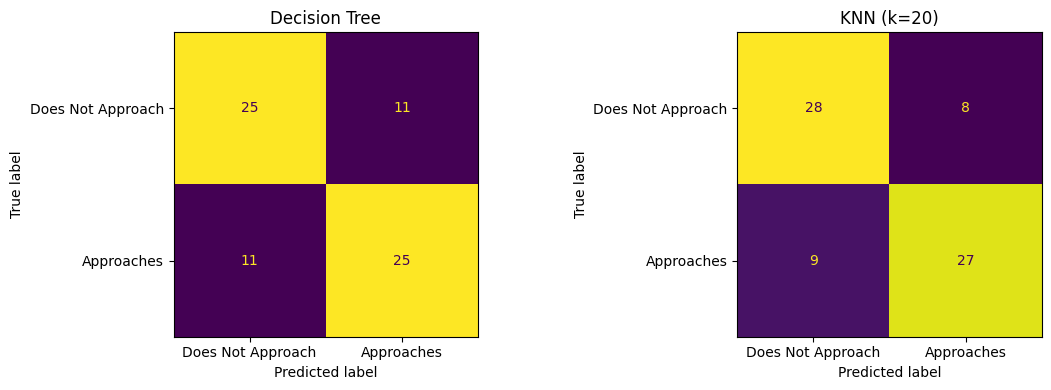

In [208]:
# 5.4 Confusion matrices — side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=['Does Not Approach', 'Approaches'],
    ax=axes[0], colorbar=False
)
axes[0].set_title('Decision Tree')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_knn,
    display_labels=['Does Not Approach', 'Approaches'],
    ax=axes[1], colorbar=False
)
axes[1].set_title(f'KNN (k={best_k})')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [209]:
# 5.5 Cross-validation comparison
# Use X and y from df_balanced (same data used for training)
# KNN: wrap in Pipeline to prevent data leakage in CV
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_cv_f1 = cross_val_score(dt, X, y, cv=cv, scoring="f1")

knn_pipeline = Pipeline([
    ("scaler", MinMaxScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=best_k))
])
knn_cv_f1 = cross_val_score(knn_pipeline, X, y, cv=cv, scoring="f1")

print(f"Decision Tree  CV F1: {dt_cv_f1.mean():.3f} +/- {dt_cv_f1.std():.3f}")
print(f"KNN (k={best_k})      CV F1: {knn_cv_f1.mean():.3f} +/- {knn_cv_f1.std():.3f}")
print()
print("Per-fold DT F1: ", [round(x,3) for x in dt_cv_f1])
print("Per-fold KNN F1:", [round(x,3) for x in knn_cv_f1])


Decision Tree  CV F1: 0.733 +/- 0.031
KNN (k=20)      CV F1: 0.765 +/- 0.040

Per-fold DT F1:  [np.float64(0.771), np.float64(0.714), np.float64(0.754), np.float64(0.684), np.float64(0.74)]
Per-fold KNN F1: [np.float64(0.817), np.float64(0.8), np.float64(0.763), np.float64(0.743), np.float64(0.704)]


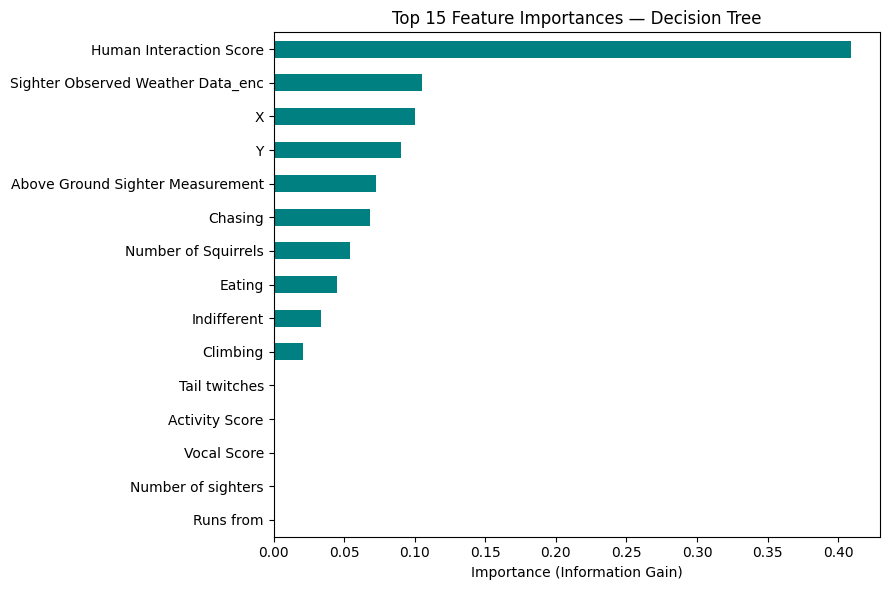

In [210]:
# 5.6 Feature Importance — Decision Tree
# KNN does not provide feature importance (distance-based), 
# so this is a key advantage of DT for interpretability
importances = pd.Series(dt.feature_importances_, index=feature_cols)
importances.sort_values(ascending=True).tail(15).plot(
    kind='barh', figsize=(9, 6), color='teal'
)
plt.title('Top 15 Feature Importances — Decision Tree')
plt.xlabel('Importance (Information Gain)')
plt.tight_layout()
plt.savefig('feature_importance_dt.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Clustering (Groups of 4)

In [211]:
# 6.1 Prepare and normalise features for clustering
# Justification: clustering is distance-based — MinMaxScaler ensures no feature
# dominates due to scale differences (as emphasised in workshop)
cluster_features = [
    'Running', 'Chasing', 'Climbing', 'Eating', 'Foraging',
    'Kuks', 'Quaas', 'Tail flags', 'Tail twitches',
    'Approaches', 'Indifferent', 'Runs from',
    'Activity Score', 'Vocal Score', 'Human Interaction Score'
]

X_cluster = df[cluster_features].copy()

# Normalise using MinMaxScaler (as in workshop)
mms = MinMaxScaler()
X_cluster_scaled = mms.fit_transform(X_cluster)
print('Features normalised for clustering')

Features normalised for clustering


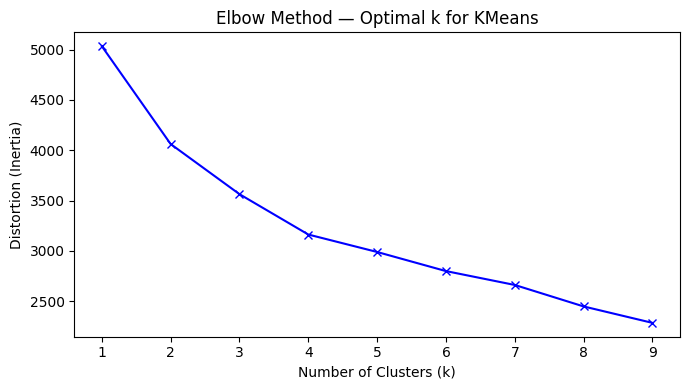

In [212]:
# 6.2 Determine optimal k — Elbow Method
distortions = []
k_range = range(1, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    distortions.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, distortions, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Distortion (Inertia)')
plt.title('Elbow Method — Optimal k for KMeans')
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [213]:
# 6.3 Clustering Method 1: KMeans
# Justification: simple, scalable, interpretable centroids
# k chosen based on elbow plot above
k_chosen = 4  # adjust based on elbow plot

km_final = KMeans(n_clusters=k_chosen, random_state=42, n_init=10)
df['KMeans Cluster'] = km_final.fit_predict(X_cluster_scaled)

print(f'KMeans (k={k_chosen}) cluster distribution:')
print(df['KMeans Cluster'].value_counts().sort_index())

KMeans (k=4) cluster distribution:
KMeans Cluster
0    923
1    664
2    646
3    790
Name: count, dtype: int64


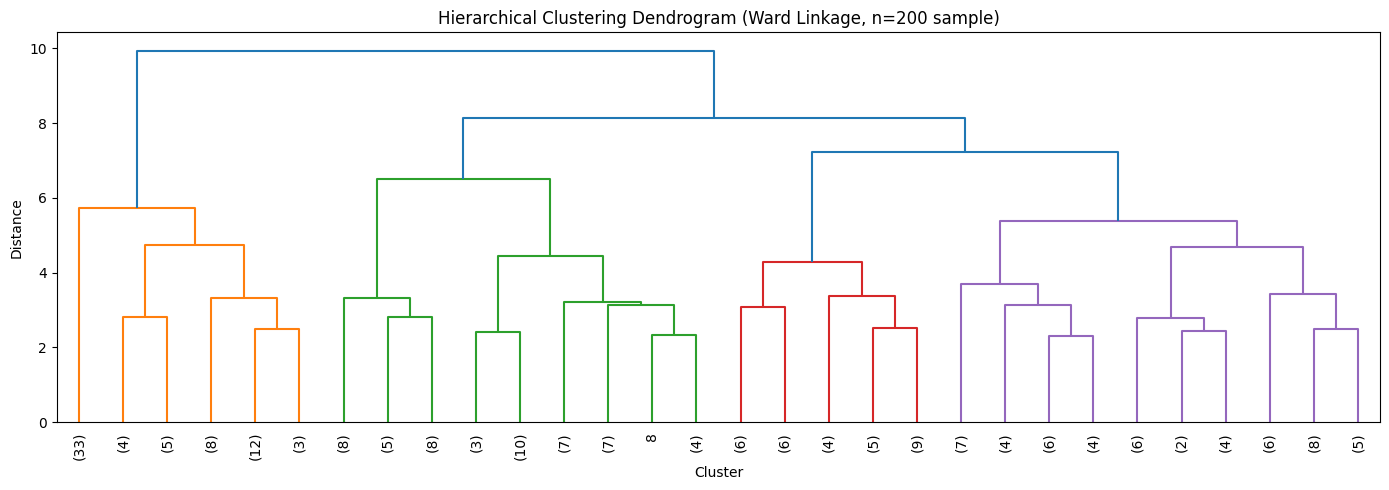

Read the dendrogram: the y-axis shows merge distance.
A large jump in distance suggests a natural cluster boundary.
HC cluster distribution (full data, Ward linkage):
HC Cluster
0    404
1    712
2    996
3    911
Name: count, dtype: int64
Adjusted Rand Index (KMeans vs HC): 0.345
ARI close to 1 = both methods agree; close to 0 = random


In [214]:
# 6.4 Clustering Method 2: Hierarchical Clustering (Agglomerative)
# Justification: doesn't require k to be specified upfront,
# dendrogram reveals natural cluster structure in the data
# Limitation vs KMeans: O(n² log n) — impractical on full 3023 rows, so use sample

# Use a sample for HC (computationally intensive on large datasets)
sample_hc = df.sample(200, random_state=42).reset_index(drop=True)
X_sample_scaled = mms.fit_transform(sample_hc[cluster_features])

# Ward linkage HC — minimises within-cluster variance at each merge step
hc = linkage(X_sample_scaled, method='ward')  # ward: minimises within-cluster variance

plt.figure(figsize=(14, 5))
dendrogram(hc, truncate_mode='lastp', p=30, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage, n=200 sample)')
plt.xlabel('Cluster')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

print('Read the dendrogram: the y-axis shows merge distance.')
print('A large jump in distance suggests a natural cluster boundary.')

# Assign HC cluster labels via fcluster (cut dendrogram at k=4)
from scipy.cluster.hierarchy import fcluster
hc_full = linkage(X_cluster_scaled, method="ward")
df["HC Cluster"] = fcluster(hc_full, t=k_chosen, criterion="maxclust") - 1  # 0-indexed

print("HC cluster distribution (full data, Ward linkage):")
print(df["HC Cluster"].value_counts().sort_index())

# Compare HC vs KMeans cluster assignment
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(df["KMeans Cluster"], df["HC Cluster"])
print(f"Adjusted Rand Index (KMeans vs HC): {ari:.3f}")
print("ARI close to 1 = both methods agree; close to 0 = random")


In [215]:
# 6.5 Profile KMeans clusters — interpret what each cluster represents
cluster_profile = df.groupby('KMeans Cluster')[cluster_features].mean().round(3)
print('KMeans Cluster Profiles:')
cluster_profile

KMeans Cluster Profiles:


,Running,Chasing,Climbing,Eating,Foraging,Kuks,Quaas,Tail flags,Tail twitches,Approaches,Indifferent,Runs from,Activity Score,Vocal Score,Human Interaction Score
KMeans Cluster,,,,,,,,,,,,,,,
0,0.226,0.115,0.242,0.213,0.408,0.043,0.027,0.027,0.120,0.155,0.0,0.000,1.205,0.219,0.000
1,0.289,0.155,0.321,0.319,0.000,0.033,0.009,0.057,0.117,0.005,1.0,0.021,1.084,0.217,1.021
2,0.379,0.062,0.251,0.235,0.415,0.045,0.012,0.073,0.180,0.025,0.0,1.000,1.342,0.313,1.000
3,0.106,0.038,0.076,0.252,1.000,0.014,0.014,0.057,0.163,0.020,1.0,0.023,1.472,0.248,1.023


Variance explained by PC1: 22.0%
Variance explained by PC2: 15.9%
Total: 37.9%


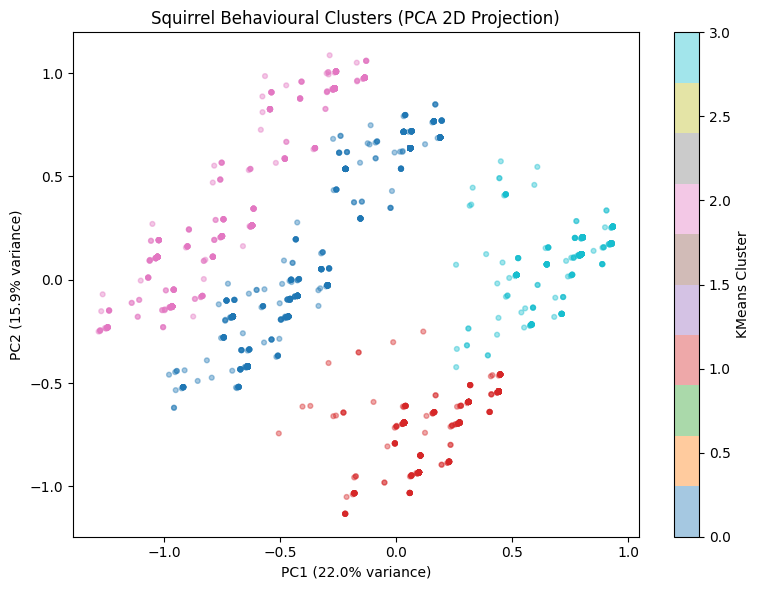

In [216]:
# 6.6 Visualise clusters using PCA (2D projection)
# Note: clustering done on original normalised features, PCA used for visualisation only
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

print(f'Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.1f}%')
print(f'Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.1f}%')
print(f'Total: {pca.explained_variance_ratio_.sum()*100:.1f}%')

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df['KMeans Cluster'], cmap='tab10', alpha=0.4, s=12)
plt.colorbar(scatter, label='KMeans Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Squirrel Behavioural Clusters (PCA 2D Projection)')
plt.tight_layout()
plt.savefig('cluster_pca.png', dpi=150, bbox_inches='tight')
plt.show()

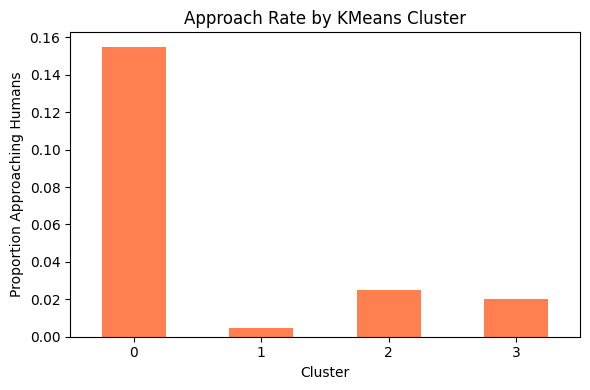

Approach rate per cluster:
KMeans Cluster
0    0.154930
1    0.004518
2    0.024768
3    0.020253
Name: Approaches, dtype: float64

Cluster sizes:
KMeans Cluster
0    923
1    664
2    646
3    790
Name: count, dtype: int64


In [217]:
# 6.7 Connect clustering back to RQ — Approaches rate per cluster
approach_by_cluster = df.groupby('KMeans Cluster')['Approaches'].mean()

plt.figure(figsize=(6, 4))
approach_by_cluster.plot(kind='bar', color='coral')
plt.title('Approach Rate by KMeans Cluster')
plt.ylabel('Proportion Approaching Humans')
plt.xlabel('Cluster')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('approach_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

print('Approach rate per cluster:')
print(approach_by_cluster)
print('\nCluster sizes:')
print(df['KMeans Cluster'].value_counts().sort_index())

Silhouette Score (k=4): 0.246
Interpretation: score closer to 1 = well-separated clusters, 0 = overlapping


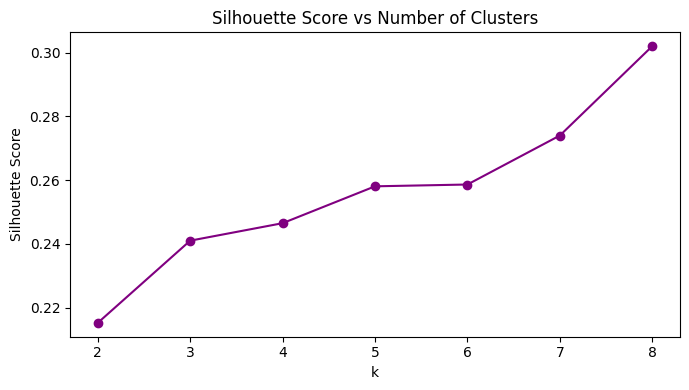

In [218]:
# 6.8 Silhouette Score — evaluate cluster quality
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_cluster_scaled, df['KMeans Cluster'])
print(f'Silhouette Score (k={k_chosen}): {sil_score:.3f}')
print('Interpretation: score closer to 1 = well-separated clusters, 0 = overlapping')

# Compare silhouette across different k values
sil_scores = []
for k in range(2, 9):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_cluster_scaled)
    sil_scores.append(silhouette_score(X_cluster_scaled, labels))

plt.figure(figsize=(7, 4))
plt.plot(range(2, 9), sil_scores, 'o-', color='purple')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')
plt.tight_layout()
plt.savefig('silhouette_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.9 Cluster Naming — Meaningful Behavioural Profiles

In [219]:
# 6.9 Assign meaningful names to clusters based on their profiles
# This is what the rubric requires: clusters must be interpretable,
# not just labelled as 0, 1, 2, 3

# Re-run cluster profile on key interpretable features
key_features = [
    "Running", "Chasing", "Climbing", "Eating", "Foraging",
    "Kuks", "Tail flags", "Tail twitches",
    "Approaches", "Indifferent", "Runs from",
    "Activity Score", "Vocal Score", "Human Interaction Score"
]

profile = df.groupby("KMeans Cluster")[key_features].mean().round(3)

# Auto-suggest cluster names based on dominant features
cluster_names = {
    0: 'Human-approachers',   # high Approaches (0.155), low Runs from
    1: 'Passive observers',   # high Indifferent, moderate activity
    2: 'Human-avoiders',      # high Runs from (1.0), high Vocal Score
    3: 'Active foragers'      # Foraging=1.0, Indifferent=1.0
}

print("Proposed cluster names:")
for k, v in cluster_names.items():
    print(f"  Cluster {k}: {v}")

df["Cluster Name"] = df["KMeans Cluster"].map(cluster_names)

# Summary table
summary = df.groupby("Cluster Name")[key_features + ["KMeans Cluster"]].agg(
    {**{f: "mean" for f in key_features}, "KMeans Cluster": "count"}
).rename(columns={"KMeans Cluster": "Count"}).round(3)
summary.insert(0, "Count", summary.pop("Count"))
print("Cluster Summary Table:")
print(summary.to_string())


Proposed cluster names:
  Cluster 0: Human-approachers
  Cluster 1: Passive observers
  Cluster 2: Human-avoiders
  Cluster 3: Active foragers
Cluster Summary Table:
                   Count  Running  Chasing  Climbing  Eating  Foraging   Kuks  Tail flags  Tail twitches  Approaches  Indifferent  Runs from  Activity Score  Vocal Score  Human Interaction Score
Cluster Name                                                                                                                                                                                      
Active foragers      790    0.106    0.038     0.076   0.252     1.000  0.014       0.057          0.163       0.020          1.0      0.023           1.472        0.248                    1.023
Human-approachers    923    0.226    0.115     0.242   0.213     0.408  0.043       0.027          0.120       0.155          0.0      0.000           1.205        0.219                    0.000
Human-avoiders       646    0.379    0.062     0.251  

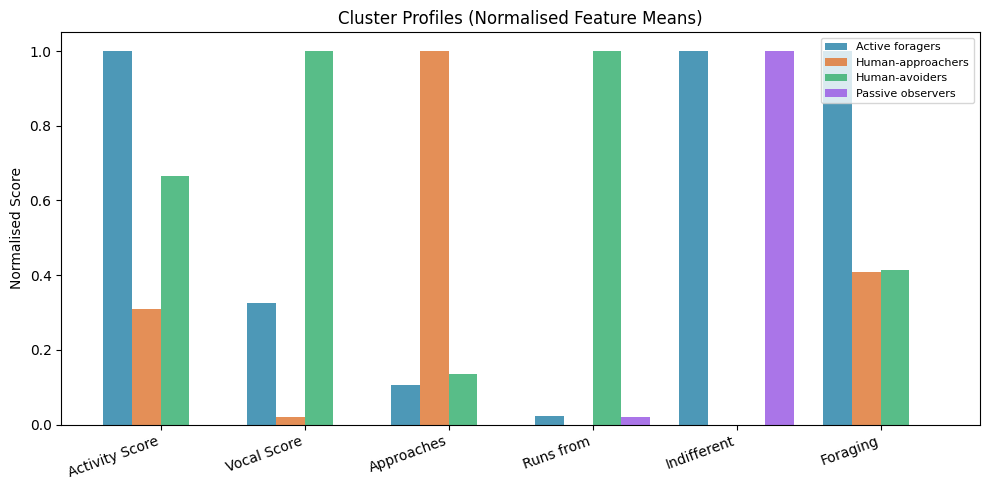

Approach rate per cluster (connection to RQ):
Cluster Name
Human-approachers    0.155
Human-avoiders       0.025
Active foragers      0.020
Passive observers    0.005
Name: Approaches, dtype: float64


In [220]:
# Radar/bar chart showing cluster profiles for report
plot_features = ["Activity Score", "Vocal Score", "Approaches",
                 "Runs from", "Indifferent", "Foraging"]

profile_plot = df.groupby("Cluster Name")[plot_features].mean()

# Normalise to 0-1 for visual comparison
profile_norm = (profile_plot - profile_plot.min()) / (profile_plot.max() - profile_plot.min() + 1e-8)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(plot_features))
width = 0.8 / len(profile_norm)
colors = ["#2e86ab", "#e07b39", "#3bb273", "#9b5de5", "#f15bb5", "#aaa"]

for i, (cluster_name, row) in enumerate(profile_norm.iterrows()):
    ax.bar(x + i * width, row[plot_features], width,
           label=cluster_name, color=colors[i % len(colors)], alpha=0.85)

ax.set_xticks(x + width * (len(profile_norm) - 1) / 2)
ax.set_xticklabels(plot_features, rotation=20, ha="right")
ax.set_title("Cluster Profiles (Normalised Feature Means)")
ax.set_ylabel("Normalised Score")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("cluster_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

# Approaches rate per named cluster
approach_rate = df.groupby("Cluster Name")["Approaches"].mean().sort_values(ascending=False)
print("Approach rate per cluster (connection to RQ):")
print(approach_rate.round(3))


## 7. Summary

| Section | Methods Used | Key Justification |
|---|---|---|
| Preprocessing | Missing value imputation, data validation, feature engineering, stratified undersampling, data merging | Handle quality issues; balance class imbalance; enrich with environmental data |
| Correlation | Pearson + NMI (with discretization) | Pearson for linear; NMI for non-linear; comparison reveals additional structure |
| Supervised Learning | Decision Tree (entropy/IG) + KNN | DT: interpretable, visualisable; KNN: distance-based complement; both evaluated with F1 + CV |
| Clustering | KMeans (elbow + silhouette) + Hierarchical (dendrogram) | KMeans: scalable profiles; HC: reveals natural groupings without specifying k |

**Causal language reminder:** All correlation findings use 'is associated with' — not 'causes'.